In [2]:
from google_play_scraper import reviews_all, Sort
import pandas as pd

print("Mulai scraping...")

ipusnas_reviews = reviews_all(
    'mam.reader.ipusnas',
    sleep_milliseconds=0,
    lang='id',
    country='id',
    sort=Sort.NEWEST
)

print("Scraping selesai!")

# Convert ke DataFrame
df = pd.DataFrame(ipusnas_reviews)

print("Jumlah review yang berhasil diambil:", len(df))

# Simpan ke CSV
df.to_csv("ipusnas_reviews_all.csv", index=False)

df.head()

Mulai scraping...
Scraping selesai!
Jumlah review yang berhasil diambil: 20321


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,ca67979d-ed39-4864-9f90-b32dd12a60a0,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Setelah update sdh seperti semua, terimakasih ...",4,0,2.1.2,2026-03-30 22:28:48,None,NaT,2.1.2
1,ad3c1c25-05f3-40eb-b95b-385476595427,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sudah sangat niat mau literasi baca disini yg ...,1,0,2.1.2,2026-03-30 17:47:00,None,NaT,2.1.2
2,db27ab64-ab36-46ec-8763-4af00069772d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,TERIMA KASIH BANYAK AUDAH DIPERBAIKI... Semoga...,5,0,2.1.2,2026-03-30 14:24:43,None,NaT,2.1.2
3,a55e2646-e13d-463d-8992-338d3fa0dcf7,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,halo i pusnas kenapa sekarang pinjam buku jadi...,5,0,None,2026-03-30 06:03:49,None,NaT,None
4,b40cfde1-61b3-402c-97eb-831a3dc2cd70,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"semenjak aplikasi crash Mulu,jadi sebel kalau ...",2,1,2.1.2,2026-03-29 10:02:38,None,NaT,2.1.2


In [3]:
# Exploratory Data Analysis (EDA) - Awal
df.shape

(20321, 11)

In [4]:
df.describe()

,score,thumbsUpCount,at,repliedAt
count,20321.000000,20321.000000,20321,13126
mean,2.833079,1.885143,2022-05-21 01:22:37.396880128,2020-10-06 17:16:05.548453376
min,1.000000,0.000000,2016-08-16 14:28:20,2016-12-02 08:32:38
25%,1.000000,0.000000,2019-11-28 20:41:59,2019-05-24 08:14:03.249999872
50%,3.000000,0.000000,2021-11-26 10:07:08,2020-07-26 13:34:13
75%,5.000000,0.000000,2025-01-20 21:28:00,2021-11-25 09:18:35.249999872
max,5.000000,2284.000000,2026-03-30 22:28:48,2025-09-09 14:50:16
std,1.658755,24.703986,NaN,NaN


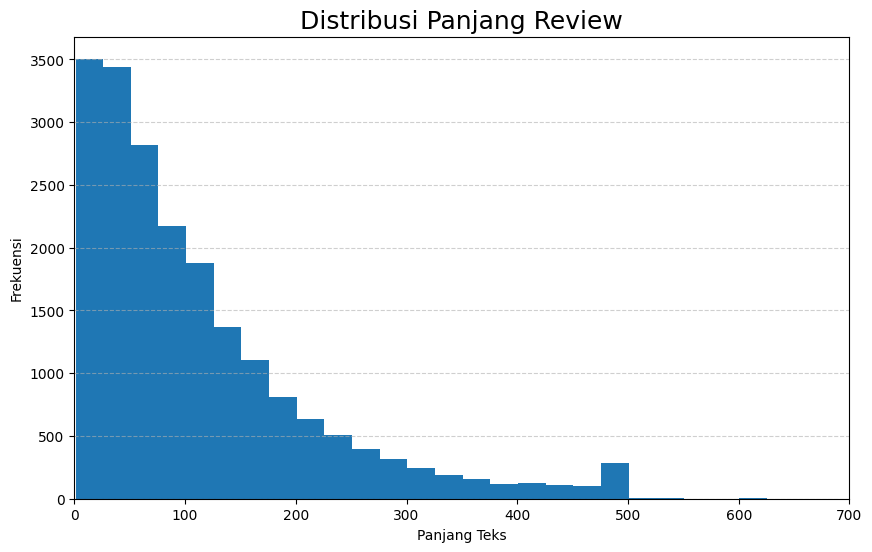

In [5]:
import matplotlib.pyplot as plt

text_column = 'content' 

df['text_length'] = df['content'].astype(str).apply(len)

plt.figure(figsize=(10,6))
plt.hist(df['text_length'], bins=50)

plt.title("Distribusi Panjang Review", fontsize=18)
plt.xlabel("Panjang Teks")
plt.ylabel("Frekuensi")

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.xlim(0, 700)

plt.show()

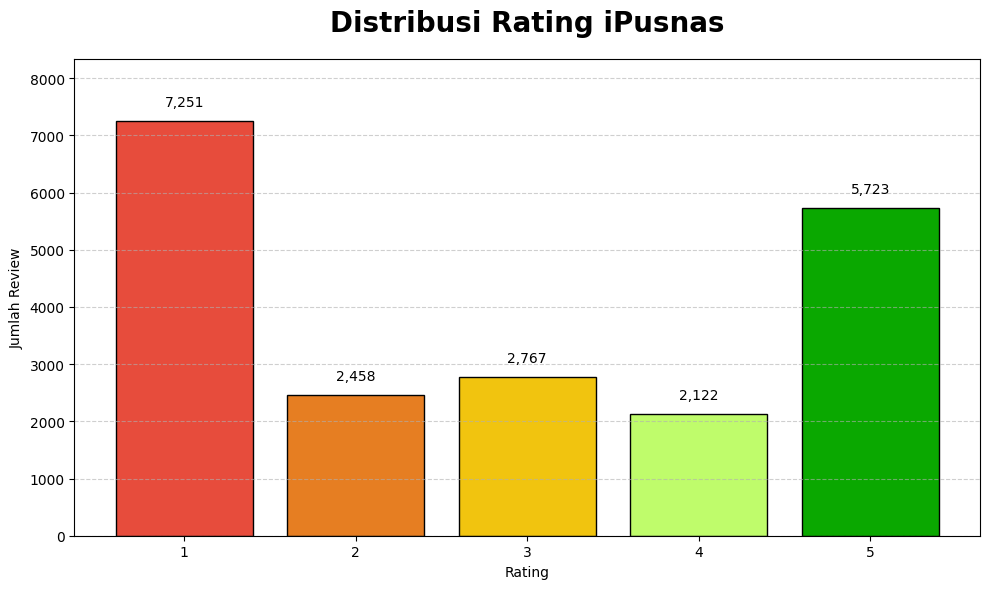

In [6]:
df_count = df['score'].value_counts().sort_index()

score_colors = {
    1: '#e74c3c',
    2: '#e67e22',
    3: '#f1c40f',
    4: '#bffc6b',
    5: '#0aa800',
}

colors = [score_colors[score] for score in df_count.index]

plt.figure(figsize=(10, 6))

bars = plt.bar(df_count.index, df_count.values, color=colors, edgecolor='black')

plt.title('Distribusi Rating iPusnas', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('Rating')
plt.ylabel('Jumlah Review')

max_val = max(df_count.values)
plt.ylim(top=max_val * 1.15)

plt.grid(axis='y', linestyle='--', alpha=0.6)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + max_val * 0.03,
        f"{height:,}",
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

In [7]:
from collections import Counter

all_text = ' '.join(df['content'].dropna().astype(str)).lower()
words = all_text.split()

word_counts = Counter(words)
common_words = word_counts.most_common(20)

word_freq_df = pd.DataFrame(common_words, columns=['Word','Frequency'])
display(word_freq_df)

,Word,Frequency
0,bisa,8736
1,buku,6973
2,saya,5732
3,di,5416
4,aplikasi,5018
5,dan,4765
6,tidak,4565
7,yang,4272
8,ini,4145
9,ada,3229


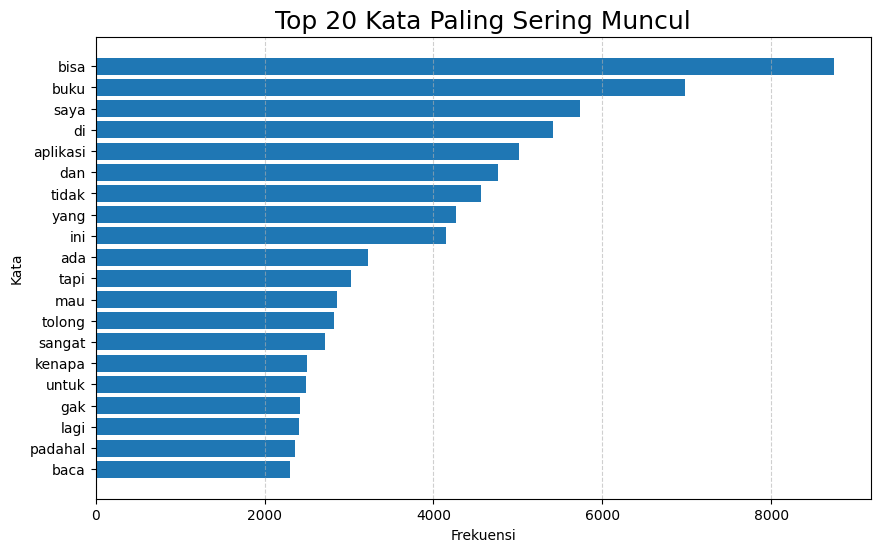

In [8]:
plt.figure(figsize=(10,6))

plt.barh(word_freq_df['Word'][::-1], word_freq_df['Frequency'][::-1])

plt.title("Top 20 Kata Paling Sering Muncul", fontsize=18)
plt.xlabel("Frekuensi")
plt.ylabel("Kata")

plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.show()

In [9]:
print("Jumlah data:", len(df))
print("Rata-rata panjang review:", df['text_length'].mean())
print("Review terpanjang:", df['text_length'].max())
print("Review terpendek:", df['text_length'].min())

Jumlah data: 20321
Rata-rata panjang review: 111.77510949264308
Review terpanjang: 1250
Review terpendek: 1


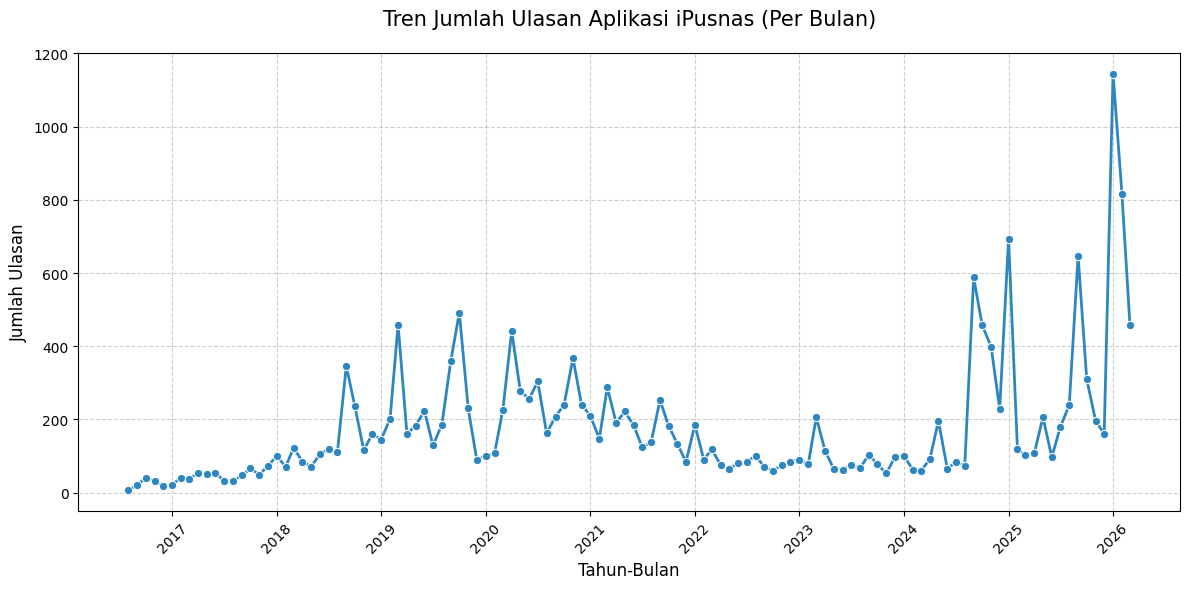

In [10]:
import seaborn as sns
# =========================
# TREND ANALYSIS
# =========================

df['at'] = pd.to_datetime(df['at'])

df['month_year'] = df['at'].dt.to_period('M')
trend_data = df.groupby('month_year').size().reset_index(name='jumlah_ulasan')

trend_data['month_year'] = trend_data['month_year'].dt.to_timestamp()
plt.figure(figsize=(12, 6))
sns.lineplot(data=trend_data, x='month_year', y='jumlah_ulasan', marker='o', color='#2E86C1', linewidth=2)

# Menambahkan judul dan label
plt.title('Tren Jumlah Ulasan Aplikasi iPusnas (Per Bulan)', fontsize=15, pad=20)
plt.xlabel('Tahun-Bulan', fontsize=12)
plt.ylabel('Jumlah Ulasan', fontsize=12)

# Mengatur agar grid terlihat rapi
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [11]:
# ---- WEEK 3 ------
import nltk
from nltk.corpus import stopwords
stop_words = set(stopwords.words('indonesian'))

In [12]:
# =========================
# STEMMER
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

factory = StemmerFactory()
stemmer = factory.create_stemmer()

# PROTECTED WORDS
protected_words = {
    'perpus','ipusnas','login','logout','email','password',
    'ebook','server','bug','error','aplikasi'
}

In [13]:
normalization_dict = {
    'gak': 'tidak','ga': 'tidak','g': 'tidak','nggak': 'tidak','engga': 'tidak','tdk': 'tidak','gk': 'tidak',
    'blm': 'belum',
    'bgt': 'banget', 'bgt' : 'bangt',
    'krn': 'karena','krna': 'karena','karna': 'karena',
    'unduh':'download','didownload':'download','diunduh':'download',
    'udah': 'sudah','sdh': 'sudah',
    'dpt': 'dapat','dapet': 'dapat',
    'ksh': 'kasih',
    'km': 'kamu',
    'pdhl':'padahal','knp':'kenapa',
    'eror':'error','ngebug':'bug',
    'app':'aplikasi','apknya':'aplikasi','aplikasinya':'aplikasi',
    'masuk':'login','keluar':'logout',
    'minjam':'pinjam','pinjem':'pinjam','meminjam':'pinjam',
    'diupdate':'update','diperbarui':'update',
    'lemot':'lambat',
    'trs':'terus','trus':'terus',
    'pake':'pakai','nyari':'cari','pengen':'ingin',
    'perpus':'perpustakaan',
}

def normalize_words(tokens):
    return [normalization_dict[word] if word in normalization_dict else word for word in tokens]

In [40]:
# Custom stopwords 
manual_stopwords = {
    'yang','dan','di','ke','dari','ini','ni','itu','ada','nya',
    'buat','untuk','utk','saya','aku','lagi','lg','tapi','kalau','kalo',
    'cuma','saja','hanya','juga','pas','mau','saat','akan',
    'dengan','kok','sih','dong','ya','apa','kenapa','mengapa',
    'bagaimana','mana','karena','jadi','terus','lalu',
    'kak','min','admin','aplikasi','apk', 'kok'
    'nih','tuh','lah','deh', 'yg','aja','sih','loh',
    'secara','tersebut','sebuah','malah','justru', 'padahal', 'kenapa',
    'supaya','agar',
    'gitu','begini','begitu',
    'setiap','semua','banyak','beberapa',
    'tadi','sekarang','nanti','dulu',
    'kyk','kayak','kaya',
    'krn','krna','karna',
    'emang','memang',
    'masa','ampe','sampai','hingga',
    'dpt','dapat','dapet',
    'kasih','ksh','beri','berikan',
    'mohon','tolong',
    'km','kamu','si',
    'sang','para','kaum',
    'kita','kami','anda','dia','ia','mereka','beliau','kalian',
    'sendiri','sama','atau','dalam','kali','seperti','ketika',
    'lain','tetap','versi','pada','namun','pun',
    'satu','orang','bagi','kan','soalnya','nih',
    'jika','bahkan','apalagi','cara','halo','eh',
    'sehingga','menjadi','adanya','jumlah','tahun'
    # conversational / filler
    'padahal','semoga','terima','terimakasih','makasih',
    'maaf','harap','alhamdulillah','salam',
    
    # vague / non-informative
    'coba','ingin','mungkin','kadang','langsung',
    'awal','akhir','akhirnya','terakhir',
    'segera','kembali','biar','bikin',
    
    # general verbs (kurang meaningful sendiri)
    'membuat','membuka','menggunakan','digunakan',
    'menambah','ditambah','ditambahkan','tambahkan',
    'meningkatkan','ditingkatkan',
    
    # waktu (kalau tidak dianalisis)
    'hari','kemarin','minggu','bulan','sebelum','setelah',
    
    # noise / typo / singkatan tambahan
    'tp','tpi','udh','dah','trs','trus','jg','jd','bs',
    'klo','pdhl','knp','sy','d',
    
    # conversational Indo banget
    'bener','oke','ok','yah','yaa','ko','nih','tuh',
    
    # low info
    'hal','nama','kata','bilang'
}

keep_words = {
    'tidak','gak','ga','nggak','engga','tdk','belum','blm',
    'banget','bgt','sangat','amat','terlalu',
    'harus','perlu','wajib','butuh', 'anggaran'
    'sering','jarang','pernah','selalu',
    'rasanya','terasa','kelihatannya','sepertinya'
}

In [15]:
# =========================
# 🆕 TAMBAHAN: STEM FUNCTION
def stem_words(tokens):
    stemmed = []
    for word in tokens:
        if word in protected_words:
            stemmed.append(word)
        else:
            stemmed.append(stemmer.stem(word))
    return stemmed
# =========================
def preprocess_text(text):
    if pd.isna(text):
        return []
    
    text = text.lower()
    tokens = text.split()
    
    tokens = normalize_words(tokens)
    tokens = [word for word in tokens if word not in stop_words and word not in manual_stopwords]
    tokens = stem_words(tokens)
    
    return tokens

In [16]:
# =========================
# 1. CLEANING
import re
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['content'].astype(str).apply(clean_text)

df['clean_text']

0        setelah update sdh seperti semua terimakasih d...
1        sudah sangat niat mau literasi baca disini yg ...
2        terima kasih banyak audah diperbaiki semoga ba...
3        halo i pusnas kenapa sekarang pinjam buku jadi...
4        semenjak aplikasi crash mulujadi sebel kalau b...
                               ...                        
20316                                                keren
20317                                    semoga bermanfaat
20318                     sesuai dengan kebutuhan saat ini
20319                                            deskripsi
20320                                         di coba dulu
Name: clean_text, Length: 20321, dtype: object

In [17]:
# =========================
# 2. TOKENIZATION
# =========================
df['tokens'] = df['clean_text'].apply(lambda x: x.split())

df['tokens'].head()

0    [setelah, update, sdh, seperti, semua, terimak...
1    [sudah, sangat, niat, mau, literasi, baca, dis...
2    [terima, kasih, banyak, audah, diperbaiki, sem...
3    [halo, i, pusnas, kenapa, sekarang, pinjam, bu...
4    [semenjak, aplikasi, crash, mulujadi, sebel, k...
Name: tokens, dtype: object

In [18]:
# =========================
# 3. STEMMING
# =========================
df['stemmed'] = df['tokens'].apply(stem_words)
df['stemmed']

0        [telah, update, sdh, seperti, semua, terimakas...
1        [sudah, sangat, niat, mau, literasi, baca, sin...
2        [terima, kasih, banyak, audah, baik, moga, ban...
3        [halo, i, pusnas, kenapa, sekarang, pinjam, bu...
4        [semenjak, aplikasi, crash, mulujadi, sebel, k...
                               ...                        
20316                                              [keren]
20317                                      [moga, manfaat]
20318                   [sesuai, dengan, butuh, saat, ini]
20319                                          [deskripsi]
20320                                     [di, coba, dulu]
Name: stemmed, Length: 20321, dtype: object

In [19]:
# =========================
#  4. NORMALIZATION
# =========================
df['normalized'] = df['stemmed'].apply(normalize_words)
df['normalized']

0        [telah, update, sudah, seperti, semua, terimak...
1        [sudah, sangat, niat, mau, literasi, baca, sin...
2        [terima, kasih, banyak, audah, baik, moga, ban...
3        [halo, i, pusnas, kenapa, sekarang, pinjam, bu...
4        [semenjak, aplikasi, crash, mulujadi, sebel, k...
                               ...                        
20316                                              [keren]
20317                                      [moga, manfaat]
20318                   [sesuai, dengan, butuh, saat, ini]
20319                                          [deskripsi]
20320                                     [di, coba, dulu]
Name: normalized, Length: 20321, dtype: object

In [20]:
# =========================
# 5. STOPWORDS REMOVAL
# =========================
df['filtered'] = df['normalized'].apply(
    lambda words: [word for word in words if (word not in manual_stopwords) or (word in keep_words)]
)

print("===RESULT AFTER STOPWORDS REMOVAL===")
df[['content','normalized','stemmed','filtered']].head()

===RESULT AFTER STOPWORDS REMOVAL===


,content,normalized,stemmed,filtered
0,"Setelah update sdh seperti semua, terimakasih ...","[telah, update, sudah, seperti, semua, terimak...","[telah, update, sdh, seperti, semua, terimakas...","[telah, update, sudah, developer, jujur, sanga..."
1,sudah sangat niat mau literasi baca disini yg ...,"[sudah, sangat, niat, mau, literasi, baca, sin...","[sudah, sangat, niat, mau, literasi, baca, sin...","[sudah, sangat, niat, literasi, baca, sini, mu..."
2,TERIMA KASIH BANYAK AUDAH DIPERBAIKI... Semoga...,"[terima, kasih, banyak, audah, baik, moga, ban...","[terima, kasih, banyak, audah, baik, moga, ban...","[audah, baik, moga, bangsa, indonesia, salah, ..."
3,halo i pusnas kenapa sekarang pinjam buku jadi...,"[halo, i, pusnas, kenapa, sekarang, pinjam, bu...","[halo, i, pusnas, kenapa, sekarang, pinjam, bu...","[i, pusnas, pinjam, buku, susah, tidak, bisa, ..."
4,"semenjak aplikasi crash Mulu,jadi sebel kalau ...","[semenjak, aplikasi, crash, mulujadi, sebel, k...","[semenjak, aplikasi, crash, mulujadi, sebel, k...","[semenjak, crash, mulujadi, sebel, baca, disin..."


In [28]:
# =========================
# WORD FREQUENCY AFTER STOPWORDS REMOVAL
all_words = [word for row in df['filtered'] for word in row]

word_counts = Counter(all_words)
common_words = word_counts.most_common(30)

word_freq_df = pd.DataFrame(common_words, columns=['Word','Frequency'])
display(word_freq_df)

,Word,Frequency
0,tidak,11055
1,buku,10241
2,bisa,9512
3,baca,5005
4,sudah,4014
5,baik,4011
6,pinjam,3871
7,login,3865
8,bagus,3180
9,ipusnas,2760


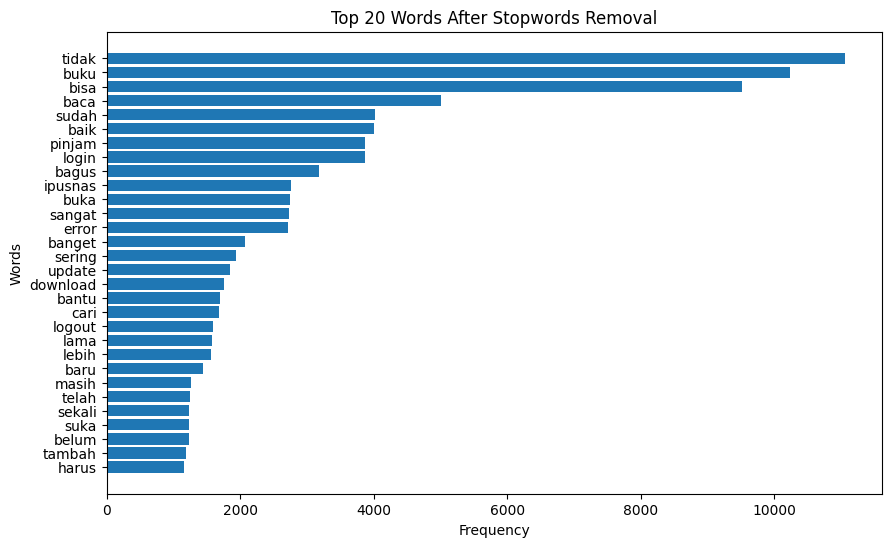

In [29]:
# =========================
# VISUALISASI
# =========================
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(word_freq_df['Word'][::-1], word_freq_df['Frequency'][::-1])
plt.title("Top 20 Words After Stopwords Removal")
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.show()

In [30]:
# EDA - Analisis Teks Pasca-Preprocessing

You should consider upgrading via the '/Users/nida/Documents/#1 kulyah/smst 8/PBA/scraping_env/bin/python -m pip install --upgrade pip' command.


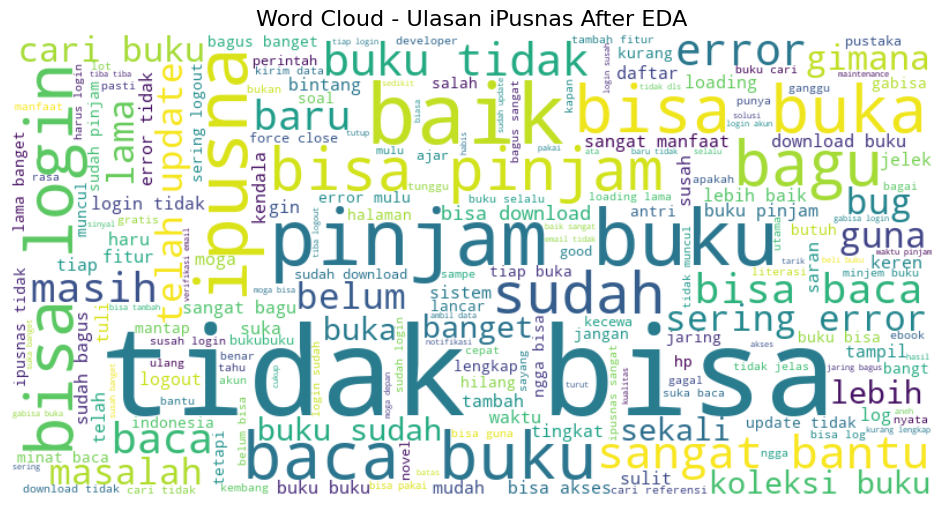

In [31]:
import sys
!"{sys.executable}" -m pip install wordcloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text_after = ' '.join([' '.join(map(str, l)) for l in df['filtered']])

wordcloud = WordCloud(width=800, height=400, 
                      background_color='white', 
                      colormap='viridis').generate(text_after)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Ulasan iPusnas After EDA', fontsize=16)
plt.show()

/var/folders/wy/pyy9phgx4kngk0b6dmzdhvdh0000gn/T/ipykernel_99748/4052252906.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=y, y=x, palette='rocket')


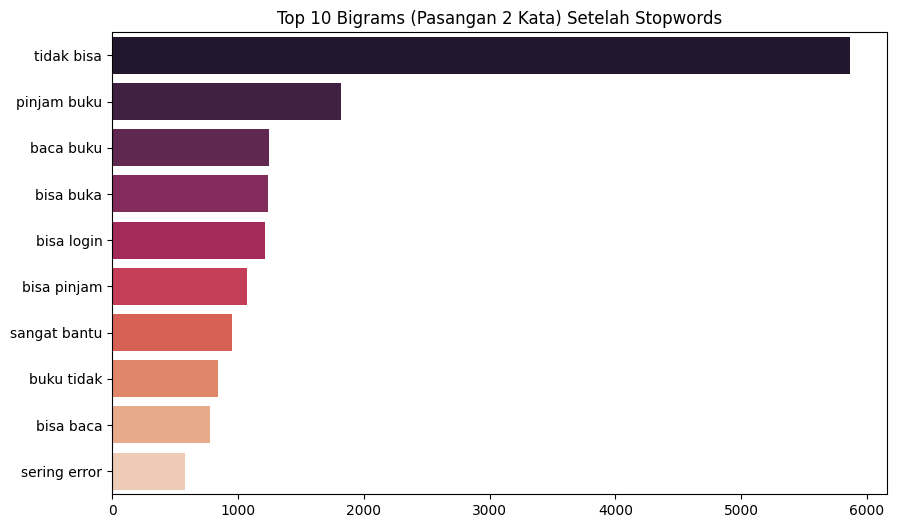

In [32]:
from sklearn.feature_extraction.text import CountVectorizer

def get_top_ngram(corpus, n=None):
    vec = CountVectorizer(ngram_range=(n, n)).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:10]

# MENGUBAH LIST MENJADI STRING untuk keperluan N-Gram
df_string = df['filtered'].apply(lambda x: ' '.join(map(str, x)))

# Mengambil 10 Bigram teratas
top_bigrams = get_top_ngram(df_string, 2)
x, y = map(list, zip(*top_bigrams))

plt.figure(figsize=(10, 6))
sns.barplot(x=y, y=x, palette='rocket')
plt.title('Top 10 Bigrams (Pasangan 2 Kata) Setelah Stopwords')
plt.show()

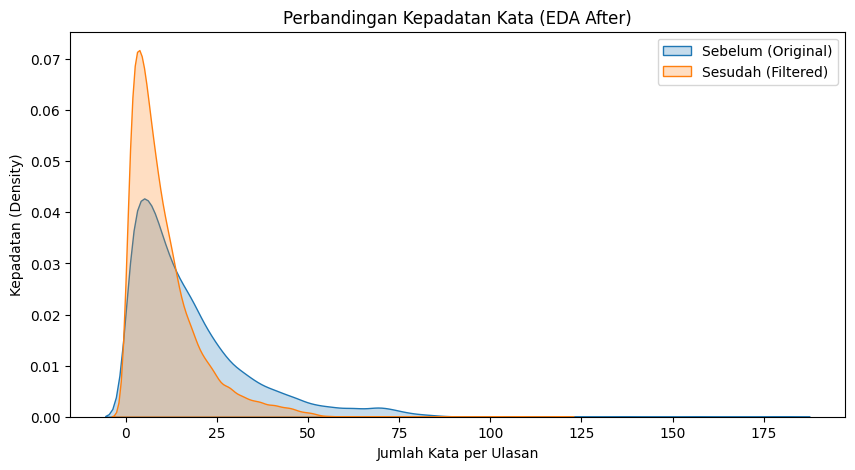

Rata-rata kata asli: 17.3 kata
Rata-rata kata bersih: 10.5 kata


In [33]:
# Karena 'filtered' isinya list, kita cukup hitung panjang list-nya (len)
df['word_count_before'] = df['content'].apply(lambda x: len(str(x).split()))
df['word_count_after'] = df['filtered'].apply(lambda x: len(x)) # Menghitung jumlah item dalam list

# Plotting
plt.figure(figsize=(10, 5))
sns.kdeplot(df['word_count_before'], label='Sebelum (Original)', fill=True)
sns.kdeplot(df['word_count_after'], label='Sesudah (Filtered)', fill=True)

plt.title('Perbandingan Kepadatan Kata (EDA After)')
plt.xlabel('Jumlah Kata per Ulasan')
plt.ylabel('Kepadatan (Density)')
plt.legend()
plt.show()

print(f"Rata-rata kata asli: {df['word_count_before'].mean():.1f} kata")
print(f"Rata-rata kata bersih: {df['word_count_after'].mean():.1f} kata")

In [35]:
##============================
## BOW (BAG OF WORDS)
## ============================

from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# 1. Siapkan Corpus (Kumpulan kalimat yang sudah bersih)
# Kita gabungkan list kata di kolom 'filtered' menjadi string
corpus_ipusnas = df['filtered'].apply(lambda x: ' '.join(map(str, x))).tolist()

# 2. Inisialisasi CountVectorizer
cv = CountVectorizer()

# 3. Fit dan Transform menjadi matriks angka (BoW)
# .toarray() digunakan agar kita bisa melihat bentuk matriksnya seperti di contohmu
independentFeatures = cv.fit_transform(corpus_ipusnas).toarray()

# 4. Cek Hasilnya
print("Matriks BoW (Contoh 5 baris pertama):")
print(independentFeatures[:5])

# Melihat daftar kata (Vokabular) yang terbentuk
print("\nContoh 10 Kata pertama dalam Vokabular:")
print(cv.get_feature_names_out()[:100])

Matriks BoW (Contoh 5 baris pertama):
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]

Contoh 10 Kata pertama dalam Vokabular:
['aaa' 'aaaa' 'aaaaa' 'aaaaaaaaa' 'aaaaakhhhh' 'aaaamiin' 'aaaarrrggghhh'
 'aaaaw' 'aaargh' 'aababcabcd' 'aabis' 'aamiim' 'aamiin' 'aamiinn'
 'aaminn' 'aammiin' 'aaplikasi' 'aarghhhhg' 'aaya' 'ab' 'abad' 'abadi'
 'abai' 'abal' 'abalabal' 'abangkakak' 'abar' 'abarat' 'abay' 'abc'
 'abdul' 'abdullah' 'abis' 'abisin' 'abisss' 'abissss' 'abissssssss'
 'abistu' 'abjad' 'abjadau' 'abjadterbaru' 'ablikasi' 'abu' 'acak'
 'acakacakan' 'acara' 'acaraevent' 'acc' 'accessible' 'accidently'
 'account' 'aceh' 'achieving' 'achmadi' 'acount' 'acountnyaterima'
 'actually' 'acu' 'acuh' 'ad' 'adaa' 'adaaaa' 'adaada' 'adaapakah' 'adab'
 'adabukan' 'adagmn' 'adain' 'adaitu' 'adakalanya' 'adakan' 'adala'
 'adalah' 'adam' 'adan' 'adanyaaa' 'adapa' 'adapinjam' 'adaptif' 'adapun'
 'adara' 'adasuka' 'adatidak' 'adatolong' 'add' 'adddelete'

In [36]:
## =========================================================
## FEATURE EXTRACTION: BAG OF WORDS (MANUAL & AUTOMATIC)
## =========================================================

import nltk
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import numpy as np

# 1. Menyiapkan Corpus (Mengambil data yang sudah bersih dari tahap sebelumnya)
# Kita ubah list kata di kolom 'filtered' menjadi kalimat utuh (string)
corpus = df['filtered'].apply(lambda x: ' '.join(map(str, x))).tolist()

print(f"Total ulasan dalam corpus: {len(corpus)}")
print("Contoh ulasan pertama:", corpus[0])

# 2. Mencari Unique Words (Seperti contohmu)
all_words = []
for sentence in corpus:
    for word in sentence.split():
        all_words.append(word)

unique_words = sorted(list(set(all_words)))
print(f"Total kata unik (Vokabular): {len(unique_words)}")

# 3. Menghitung Frekuensi Kata (Word Frequencies)
word_frequencies = Counter(all_words)
print("\n10 Kata paling sering muncul:", word_frequencies.most_common(10))

# 4. Sorting words by frequency (Descending)
sorted_words = sorted(word_frequencies.items(), key=lambda item: item[1], reverse=True)

# 5. Creating the dictionary mapping words to numbers (Word to Number)
# Ini adalah 'Kamus' yang memetakan kata ke sebuah ID angka
word_to_number = {word: i + 1 for i, (word, freq) in enumerate(sorted_words)}

# Menampilkan 20 mapping pertama (berdasarkan frekuensi tertinggi)
print("\nWord to Number Mapping (Sorted by Frequency - Top 20):")
print(dict(list(word_to_number.items())[:20]))

# 6. Implementasi BoW dengan CountVectorizer (Versi "Bersih")
# Tips: Gunakan min_df=5 untuk membuang kata typo/aneh yang muncul kurang dari 5 kali
cv = CountVectorizer(min_df=5) 
independentFeatures = cv.fit_transform(corpus).toarray()

print("\n--- Matrix BoW (Independent Features) ---")
print(f"Bentuk Matriks (Ulasan, Kata Unik): {independentFeatures.shape}")
print(independentFeatures[:5]) # Menampilkan 5 baris pertama matriks

# 7. Melihat Vokabular yang sudah "dibersihkan" (tanpa kata 'aaa' dkk)
cleaned_vocab = cv.get_feature_names_out()
print("\n100 Kata pertama dalam Vokabular (Setelah difilter min_df=5):")
print(cleaned_vocab[:100])

Total ulasan dalam corpus: 20321
Contoh ulasan pertama: telah update sudah developer jujur sangat bantu mahasiswa
Total kata unik (Vokabular): 12279

10 Kata paling sering muncul: [('tidak', 11055), ('buku', 10241), ('bisa', 9512), ('baca', 5005), ('sudah', 4014), ('baik', 4011), ('pinjam', 3871), ('login', 3865), ('bagus', 3180), ('ipusnas', 2760)]

Word to Number Mapping (Sorted by Frequency - Top 20):
{'tidak': 1, 'buku': 2, 'bisa': 3, 'baca': 4, 'sudah': 5, 'baik': 6, 'pinjam': 7, 'login': 8, 'bagus': 9, 'ipusnas': 10, 'buka': 11, 'sangat': 12, 'error': 13, 'banget': 14, 'sering': 15, 'update': 16, 'download': 17, 'bantu': 18, 'cari': 19, 'logout': 20}

--- Matrix BoW (Independent Features) ---
Bentuk Matriks (Ulasan, Kata Unik): (20321, 2147)
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]

100 Kata pertama dalam Vokabular (Setelah difilter min_df=5):
['aamiin' 'abis' 'abjad' 'account' 'ad' 'adaa' 'adain' 'adakan' 'adalah'
 'adminnya

In [41]:
## =========================================================
## ANALISIS BoW (SAMPLE ROW 400 - 450)
## =========================================================

# 1. Mengambil subset data (Baris 400 sampai 450)
df_sample = df.iloc[400:451].copy()

# 2. Menyiapkan Corpus dari data sample tersebut
# Menggabungkan list kata di kolom 'filtered' menjadi string
corpus_sample = df_sample['filtered'].apply(lambda x: ' '.join(map(str, x))).tolist()

# 3. Proses Manual BoW (Membangun Kamus dari 50 baris ini)
all_words_sample = []
for sentence in corpus_sample:
    for word in sentence.split():
        all_words_sample.append(word)

# Frekuensi kata di 50 baris ini
word_counts_sample = Counter(all_words_sample)
print("10 Kata Terbanyak di Baris 6550-6600:", word_counts_sample.most_common(10))

# 4. Implementasi BoW dengan CountVectorizer
from sklearn.feature_extraction.text import CountVectorizer
cv_sample = CountVectorizer()
bow_matrix = cv_sample.fit_transform(corpus_sample).toarray()

# 5. Membuat DataFrame Hasil BoW agar bisa dianalisa
# Kita masukkan kolom 'score' atau 'content' asli di depan untuk perbandingan
df_bow_analysis = pd.DataFrame(bow_matrix, columns=cv_sample.get_feature_names_out())
df_bow_analysis.insert(0, 'Original_Score', df_sample['score'].values)
df_bow_analysis.insert(1, 'Cleaned_Text', corpus_sample)

print(f"\nUkuran Matriks BoW Sample: {df_bow_analysis.shape}")
display(df_bow_analysis.head())

# 6. Simpan ke Excel/CSV jika ingin dianalisa manual (opsional)
# df_bow_analysis.to_csv("analisa_bow_50_rows.csv", index=False)

10 Kata Terbanyak di Baris 6550-6600: [('tidak', 34), ('bisa', 32), ('pinjam', 27), ('buku', 25), ('error', 14), ('baca', 13), ('sudah', 11), ('data', 10), ('masalah', 9), ('baik', 9)]

Ukuran Matriks BoW Sample: (51, 208)


,Original_Score,Cleaned_Text,agam,ajaa,akses,alas,ambil,aneh,anggar,antri,...,tidak,tingkat,tulis,tulongggg,ulas,usah,waktu,warga,woii,woymana
0,1,masih erorrr belum bisa pakai,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,tidak bisa pinjam sekali sinyal terang salah a...,0,0,0,0,1,0,0,0,...,1,0,0,0,0,0,0,0,0,0
2,1,error,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,5,bagus make sudah baru rasa masalah anggar perp...,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,1,tidak bisa pinjam buku selalu muncul notif mas...,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
